In [41]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [43]:
from  sklearn.cluster import DBSCAN

x1, _ = make_blobs(n_samples=500, centers=[[-3,-3]])
x2, _ = make_blobs(n_samples=500, centers=[[3,3]])
x3 = np.random.rand(500,2) * 3 + 4
x4 = np.random.randn(10,2) * 3

x1.shape, x2.shape, x3.shape, x4.shape

((500, 2), (500, 2), (500, 2), (10, 2))

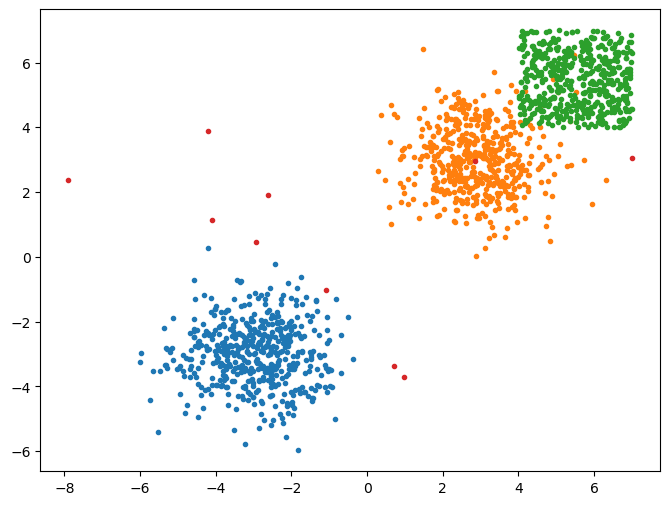

In [45]:
plt.figure(figsize=(8,6))
plt.scatter(x1[:,0], x1[:,1], marker='.')
plt.scatter(x2[:,0], x2[:,1], marker='.')
plt.scatter(x3[:,0], x3[:,1], marker='.')
plt.scatter(x4[:,0], x4[:,1], marker='.')

In [47]:
x= np.vstack([x1, x2, x3, x4])
x.shape

(1510, 2)

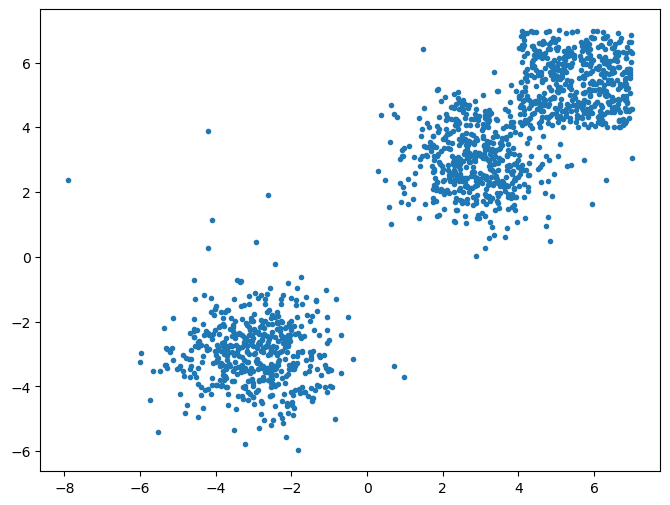

In [49]:
plt.figure(figsize=(8,6))
plt.scatter(x[:,0],x[:,1], marker='.')

In [107]:
epsilon = 0.3
minimunSamples =7

db = DBSCAN(eps=epsilon, min_samples=minimunSamples).fit(x)#모델링, 학습

label = db.labels_ # index
labels = list(set(label)) #label에서 중복 제거

print(label.shape)
print(labels)
print(db.core_sample_indices_.shape)
print(db.core_sample_indices_)

(1510,)
[0, 1, 2, 3, -1]
(1241,)
[   0    1    4 ... 1498 1499 1501]


In [109]:
#unique_labels = labels
#unique_labels

In [111]:
colors = plt.cm.Spectral(np.linspace(0,1,len(labels))) #linspace: 간격, plt.cm.Spectral: 색상 팔레트
colors


array([[0.61960784, 0.00392157, 0.25882353, 1.        ],
       [0.97485582, 0.557401  , 0.32272203, 1.        ],
       [0.99807766, 0.99923106, 0.74602076, 1.        ],
       [0.52733564, 0.8106113 , 0.64521338, 1.        ],
       [0.36862745, 0.30980392, 0.63529412, 1.        ]])

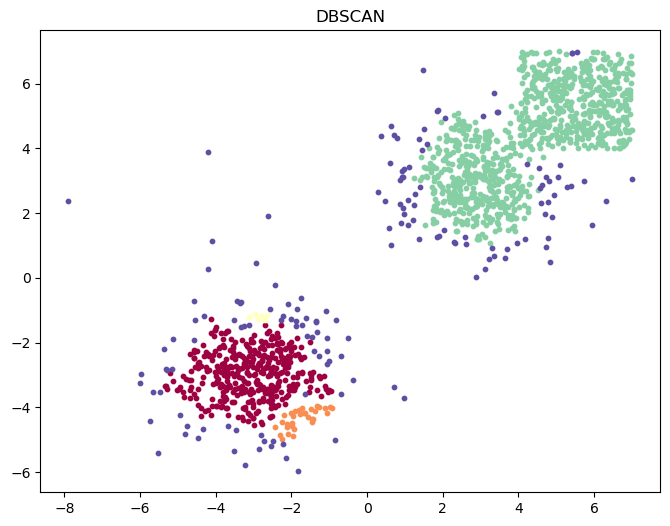

In [115]:
plt.figure(figsize=(8,6))

for k, col in zip(labels, colors):
    members = (db.labels_ == k)
    plt.scatter(x[members,0], x[members,1], color=col, marker='o', s=10)

plt.title('DBSCAN')
plt.show()